In [2]:
import pandas as pd
import torch
import torch.nn as nn
import numpy
from torchvision import datasets,transforms
from torch.utils.data import DataLoader

In [3]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [4]:
import zipfile
zip_path = "/content/Intel Image Dataset.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [20]:
transform=transforms.Compose([
    transforms.Resize((150,150)),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
])
train_data=datasets.ImageFolder(
    root="/content/seg_train/seg_train",
    transform=transform
)
test_data=datasets.ImageFolder(
    root="/content/seg_test/seg_test",
    transform=transform
)

In [21]:
image,label=train_data[0]
print(type(image))
print(image.shape)

<class 'torch.Tensor'>
torch.Size([3, 150, 150])


In [7]:
print(train_data.class_to_idx)

{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [22]:
label=[label for _,label in train_data] # so its a pretty decently balanced dataset
pd.Series(label).value_counts()

,count
3,2512
2,2404
5,2382
4,2274
1,2271
0,2191


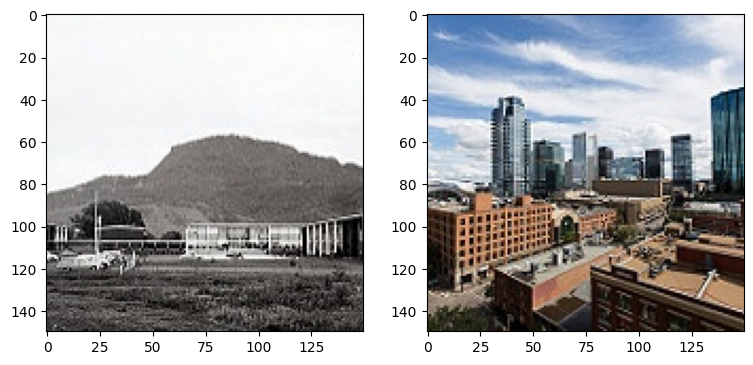

In [18]:
import matplotlib.pyplot as plt
image1,label1 = train_data[0]
image2,label2 = train_data[1]
plt.figure(figsize=(9,9))
plt.subplot(1,2,1)
plt.imshow(image1.permute(1,2,0)) # C H W to H W C
plt.subplot(1,2,2)
plt.imshow(image2.permute(1,2,0))
plt.show()

In [23]:
train_loader=DataLoader(train_data,batch_size=32,shuffle=True)
test_loader=DataLoader(test_data,batch_size=32,shuffle=True)

# First a basic CNN model

In [40]:
from functools import partial
class MyModel(nn.Module):
  def __init__(self,in_channels,out_channels):
    super().__init__()
    self.defaultConv2d=partial(
        nn.Conv2d,kernel_size=3,stride=1,padding=1,bias=False
    )
    self.defaultMaxPool2d=partial(
        nn.MaxPool2d,kernel_size=3,stride=2,padding=1
    )
    self.feature_extraction=nn.Sequential(
        self.defaultConv2d(in_channels,out_channels),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        self.defaultMaxPool2d(),

        self.defaultConv2d(out_channels,out_channels*2),
        nn.BatchNorm2d(out_channels*2),
        nn.ReLU(inplace=True),
        self.defaultMaxPool2d(),

        self.defaultConv2d(out_channels*2,out_channels*4),
        nn.BatchNorm2d(out_channels*4),
        nn.ReLU(inplace=True),
        self.defaultMaxPool2d(),

        nn.AdaptiveAvgPool2d((1,1))
    )
    self.output=nn.Sequential(
        nn.Flatten(),
        nn.LazyLinear(256),
        nn.ReLU(),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,6)
    )
  def forward(self,x):
    x=self.feature_extraction(x)
    x=self.output(x)
    return x

In [41]:
model_1=MyModel(3,32).to(device)
print(device)

cuda


In [42]:
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

lr=0.001
optimizer=Adam(params=model_1.parameters(),lr=lr)
criterion=CrossEntropyLoss()

In [43]:
print(model_1.state_dict)

<bound method Module.state_dict of MyModel(
  (feature_extraction): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
 

In [39]:
del model_1 # previous model overtrained
del optimizer
torch.cuda.empty_cache()

NameError: name 'model_1' is not defined

In [44]:
epochs=21
for epoch in range(epochs):
  train_loss=0
  test_loss=0
  train_total=0
  test_total=0
  train_acc=0
  test_acc=0
  model_1.train()
  for input,label in train_loader:
    input=input.to(device)
    label=label.to(device)
    y_preds=model_1(input)
    loss=criterion(y_preds,label)
    train_loss+=loss.item()
    pred=torch.argmax(y_preds,dim=1)
    train_acc += (pred == label).sum().item()
    train_total+=label.size(0) # 0 because .size will return a tuple, same with total_test
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss/=len(train_loader)
  train_acc/=train_total
  print(f"epoch {epoch} | training loss is {train_loss} | training accuracy is {train_acc}")
  model_1.eval()
  with torch.inference_mode():
    for input,label in test_loader:
      input=input.to(device)
      label=label.to(device)
      y_preds=model_1(input)
      loss=criterion(y_preds,label)
      test_loss+=loss.item()
      pred=torch.argmax(y_preds,dim=1)
      test_acc += (pred == label).sum().item()
      test_total+=label.size(0)
    test_loss/=len(test_loader)
    test_acc/=test_total
    print(f"epoch {epoch} | testing loss is {test_loss} | testing accuracy is {test_acc}")

epoch 0 | training loss is 1.0673144057834338 | training accuracy is 0.5203790793786518
epoch 0 | testing loss is 1.0482872280668705 | testing accuracy is 0.5513333333333333
epoch 1 | training loss is 0.8419470658742214 | training accuracy is 0.6439361550520165
epoch 1 | testing loss is 0.7824960528536046 | testing accuracy is 0.6793333333333333
epoch 2 | training loss is 0.753099842196445 | training accuracy is 0.7006555508051874
epoch 2 | testing loss is 0.6887801254683352 | testing accuracy is 0.731
epoch 3 | training loss is 0.6772909810711419 | training accuracy is 0.7435513752315804
epoch 3 | testing loss is 0.7267372953764936 | testing accuracy is 0.7273333333333334
epoch 4 | training loss is 0.6458216491484153 | training accuracy is 0.7559498361122987
epoch 4 | testing loss is 0.6280493993074336 | testing accuracy is 0.7643333333333333
epoch 5 | training loss is 0.5939550891620423 | training accuracy is 0.7825281459313097
epoch 5 | testing loss is 0.7090837666963009 | testing a

In [45]:
from sklearn.metrics import confusion_matrix

In [50]:
import os
from PIL import Image
pred_path = "/content/seg_pred/seg_pred"
image_files = os.listdir(pred_path)

images = []

for file in image_files[:4]:
  image = Image.open(os.path.join(pred_path, file)).convert("RGB")
  image = transform(image)
  images.append(image)
batch = torch.stack(images).to(device)

batch.shape

torch.Size([4, 3, 150, 150])

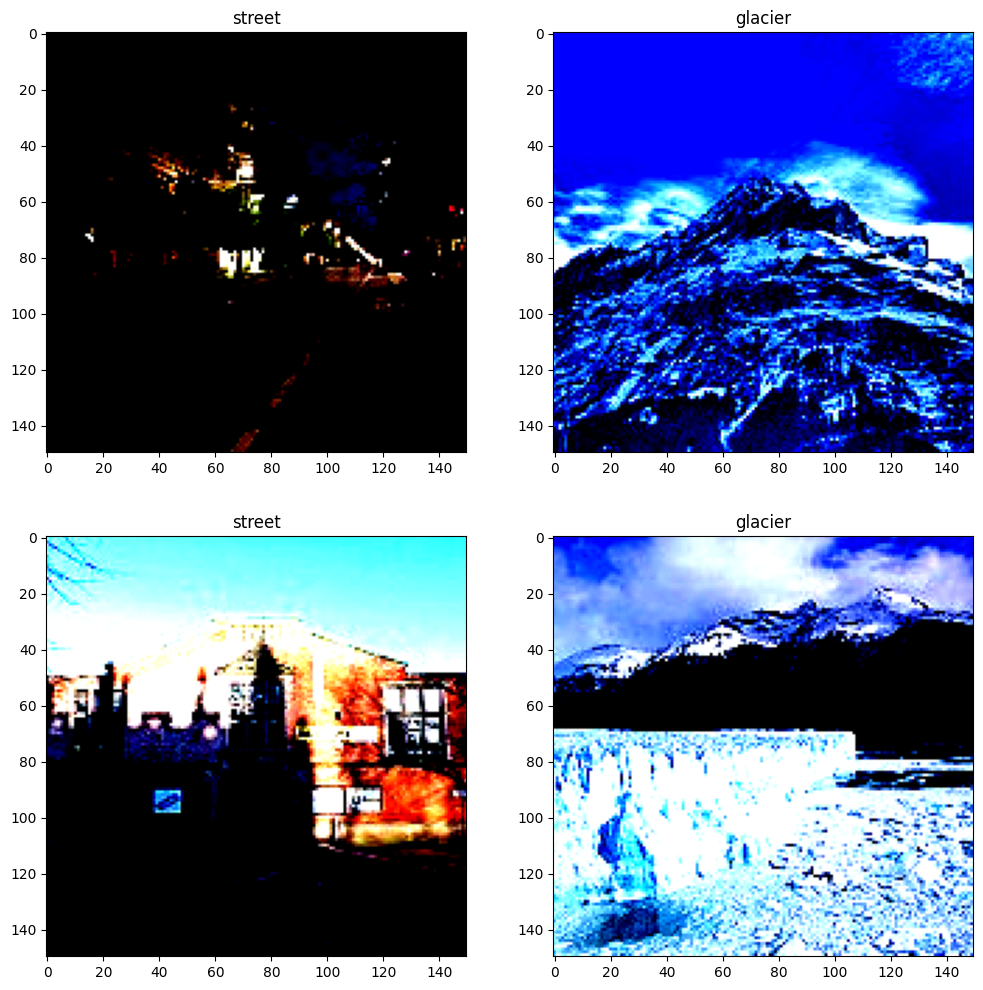

In [55]:
model_1.eval()
with torch.inference_mode():
  y_preds=model_1(batch)
  y_preds_labels=torch.argmax(y_preds,dim=1)

true_labels=train_data.classes
image1 = batch[0]
image2 = batch[1]
image3 = batch[2]
image4 = batch[3]

all_images=[image1,image2,image3,image4]

plt.figure(figsize=(12,12))
for i in range(4):
  plt.subplot(2,2,i+1)
  plt.title(true_labels[y_preds_labels[i]])
  plt.imshow(all_images[i].permute(1,2,0).cpu())
plt.show()